In [ ]:
import io
import os
import pickle
import ssl
import subprocess
import sys
import tarfile
import urllib.error
import urllib.request

import numpy as np

CIFAR_DIR = './cifar10_data'
PARQUET_URL = 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/train-00000-of-00001.parquet'
TAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
MB = 1 << 20


def _open(url):
    try:
        return urllib.request.urlopen(url)
    except (urllib.error.URLError, ssl.SSLError) as err:
        if not isinstance(getattr(err, 'reason', err), ssl.SSLError):
            raise
        print('сертификат не проверился, качаю без проверки')
        return urllib.request.urlopen(url, context=ssl._create_unverified_context())


def _download(url, path):
    """Качает файл с показом процентов. Уже скачанный не трогает."""
    if os.path.isfile(path):
        return path

    response = _open(url)
    total = int(response.headers.get('Content-Length') or 0)
    done = shown = 0
    with response, open(path + '.part', 'wb') as out:
        while chunk := response.read(MB):
            out.write(chunk)
            done += len(chunk)
            if not total:
                print(f'\rCIFAR-10  {done // MB} МБ', end='', flush=True)
            elif done == total or done - shown >= total // 20:   # шаг 5 процентов
                shown = done
                print(f'\rCIFAR-10  {done / total:5.1%}  {done // MB} из {total // MB} МБ', end='', flush=True)
    print()
    os.replace(path + '.part', path)
    return path


def _parquet_tools():
    """Возвращает pyarrow и Pillow, при надобности ставит их."""
    try:
        import pyarrow.parquet as pq
        from PIL import Image
    except ImportError:
        print('ставлю pyarrow и pillow')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow', 'pillow'], check=True)
        import pyarrow.parquet as pq
        from PIL import Image
    return pq, Image


def _from_parquet(root):
    """Зеркало Hugging Face: колонки img (PNG) и label."""
    pq, Image = _parquet_tools()
    path = _download(PARQUET_URL, os.path.join(root, 'cifar10_train.parquet'))
    table = pq.read_table(path)
    images = table.column('img').to_pylist()
    labels = np.array(table.column('label').to_pylist(), dtype=int)
    hwc = np.stack([np.array(Image.open(io.BytesIO(item['bytes'])).convert('RGB'), dtype=np.uint8)
                    for item in images])
    return hwc.transpose(0, 3, 1, 2).reshape(len(hwc), -1), labels


def _from_tar(root):
    """Оригинальный архив: пять батчей с pickle внутри."""
    archive = _download(TAR_URL, os.path.join(root, 'cifar-10-python.tar.gz'))
    batches = os.path.join(root, 'cifar-10-batches-py')
    if not os.path.isdir(batches):
        with tarfile.open(archive) as tar:
            try:
                tar.extractall(root, filter='data')   # на python 3.12 и новее
            except TypeError:
                tar.extractall(root)

    xs, ys = [], []
    for i in range(1, 6):
        with open(os.path.join(batches, f'data_batch_{i}'), 'rb') as f:
            batch = pickle.load(f, encoding='bytes')
        xs.append(batch[b'data'])
        ys.extend(batch[b'labels'])
    return np.concatenate(xs).astype('uint8'), np.array(ys, dtype=int)


def load_cifar10_train(root=CIFAR_DIR):
    """Обучающая часть целиком: (50000, 3072) uint8 в порядке R, G, B и метки (50000,)."""
    os.makedirs(root, exist_ok=True)
    try:
        return _from_parquet(root)
    except (ImportError, subprocess.CalledProcessError):
        print('pyarrow не встал, беру архив с toronto.edu, это дольше')
    except (urllib.error.URLError, TimeoutError, OSError):
        print('зеркало не отвечает, беру архив с toronto.edu, это дольше')
    return _from_tar(root)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
torch.manual_seed(37)
np.random.seed(37)
random.seed(37)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')

CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
N_CLASSES = 10

Устройство: cuda


In [3]:
LATENT_DIM = 128
VAE_EPOCHS = 30
VAE_LR = 1e-3
VAE_BATCH = 128
BETA = 1.0
NOISE_STD = 0.5
N_GENERATED = 5000

CNN_EPOCHS = 25
CNN_BATCH = 64

Загрузка CIFAR-10 из CSV
Train: (40000, 3, 32, 32) | Test: (10000, 3, 32, 32)


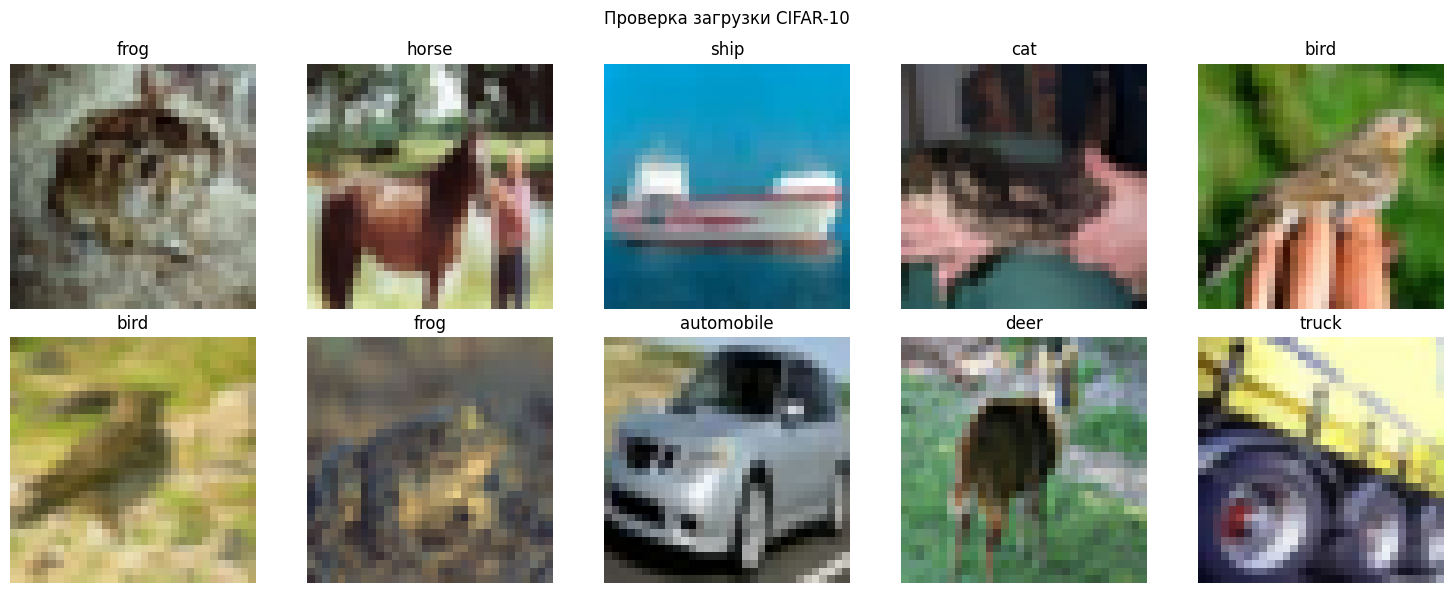

In [6]:
print('Загрузка CIFAR-10')

X_all, y_all = load_cifar10_train()   # (50000, 3072) uint8, метки (50000,)
print(f'Загружено: {X_all.shape}, классов: {len(np.unique(y_all))}')

# Сплит 40000 / 10000
X_train_flat, X_test_flat, y_train_flat, y_test_flat = train_test_split(X_all, y_all, test_size=10000, random_state=42, stratify=y_all)

def flat_to_images(X):
    """(N, 3072) uint8 -> (N, 3, 32, 32) float32 в [-1, 1]"""
    N = len(X)
    r = X[:, :1024].reshape(N, 32, 32)
    g = X[:, 1024:2048].reshape(N, 32, 32)
    b = X[:, 2048:3072].reshape(N, 32, 32)
    imgs = np.stack([r, g, b], axis=1).astype('float32')  # (N, 3, 32, 32) PyTorch CHW
    return imgs / 127.5 - 1.0  # нормализация в [-1, 1] для VAE (tanh на выходе декодера)

def flat_to_images_cnn(X):
    """(N, 3072) uint8 -> (N, 3, 32, 32) float32 в [0, 1] для CNN"""
    N = len(X)
    r = X[:, :1024].reshape(N, 32, 32)
    g = X[:, 1024:2048].reshape(N, 32, 32)
    b = X[:, 2048:3072].reshape(N, 32, 32)
    imgs = np.stack([r, g, b], axis=1).astype('float32')  # CHW
    return imgs / 255.0  # нормализация в [0, 1]

# Данные для VAE: (N, 3, 32, 32) в [-1, 1]
X_train_vae = flat_to_images(X_train_flat)
X_test_vae  = flat_to_images(X_test_flat)

# Данные для CNN: (N, 3, 32, 32) в [0, 1]
X_train_real = flat_to_images_cnn(X_train_flat)
X_test_real  = flat_to_images_cnn(X_test_flat)

print(f'Train: {X_train_vae.shape} | Test: {X_test_vae.shape}')

# Проверка
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    # Для imshow нужен HWC в [0,1]
    img = ((X_train_vae[i].transpose(1, 2, 0) + 1) / 2).clip(0, 1)
    axes[i // 5][i % 5].imshow(img)
    axes[i // 5][i % 5].set_title(CIFAR_CLASSES[y_train_flat[i]])
    axes[i // 5][i % 5].axis('off')
plt.suptitle('Проверка загрузки CIFAR-10')
plt.tight_layout(); plt.show()

In [7]:
class Encoder(nn.Module):
    """(N, 3, 32, 32) -> (mu, log_var) размера latent_dim"""
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), # (N, 32, 16, 16)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 4, stride=2, padding=1), # (N, 64, 8, 8)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1), # (N, 128, 4, 4)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # (N, 256, 2, 2)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )
        # После Flatten: 256 * 2 * 2 = 1024
        self.fc_mu = nn.Linear(256 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(256 * 2 * 2, latent_dim)

    def forward(self, x):
        h = self.conv(x) # (N, 256, 2, 2)
        h = h.view(h.size(0), -1) # (N, 1024) — flatten
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    """latent_dim -> (N, 3, 32, 32)"""
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 2 * 2)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # (N, 128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1), # (N, 64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1), # (N, 32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1), # (N, 3, 32, 32)
            nn.Tanh() # выход в [-1, 1]
        )

    def forward(self, z):
        h = self.fc(z) # (N, 1024)
        h = h.view(h.size(0), 256, 2, 2) # (N, 256, 2, 2)
        return self.deconv(h) # (N, 3, 32, 32)


class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var) # sigma = exp(log_var / 2)
        eps = torch.randn_like(std) # eps ~ N(0, I), той же формы что std
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)


def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon + beta * kl, recon, kl

In [8]:
print('Обучение VAE')

# Создаём DataLoader из numpy -> tensor
X_train_tensor = torch.tensor(X_train_vae) # (40000, 3, 32, 32)
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=VAE_BATCH, shuffle=True, num_workers=2, pin_memory=True)

vae = VAE(LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(vae.parameters(), lr=VAE_LR)

print(vae) # выводим архитектуру

train_losses, recon_losses, kl_losses = [], [], []

for epoch in range(1, VAE_EPOCHS + 1):
    vae.train()
    total_loss = total_recon = total_kl = 0.0

    for (x,) in tqdm(train_loader, desc=f'VAE Epoch {epoch}/{VAE_EPOCHS}', leave=False):
        x = x.to(DEVICE)

        optimizer.zero_grad() # обнуляем градиенты с прошлого шага
        x_hat, mu, log_var = vae(x) # прямой проход
        loss, recon, kl = vae_loss(x, x_hat, mu, log_var, beta=BETA)
        loss.backward() # обратный проход считаем градиенты
        optimizer.step() # шаг оптимизатора обновляем веса

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(train_loader)
    train_losses.append(total_loss / n)
    recon_losses.append(total_recon / n)
    kl_losses.append(total_kl / n)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss={total_loss/n:.4f} '
              f'Recon={total_recon/n:.4f} KL={total_kl/n:.4f}')

Обучение VAE
VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
      (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2)
      (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2)
      (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0.2)
    )
    (fc_mu): Linear(in_features=1024, out_features=128, bias=True)
    (fc_logvar): Line

Epoch   1 | Loss=0.2116 Recon=0.1847 KL=0.0268


Epoch   5 | Loss=0.1676 Recon=0.1348 KL=0.0328


Epoch  10 | Loss=0.1648 Recon=0.1305 KL=0.0343


Epoch  15 | Loss=0.1635 Recon=0.1281 KL=0.0353


Epoch  20 | Loss=0.1626 Recon=0.1265 KL=0.0361


Epoch  25 | Loss=0.1619 Recon=0.1255 KL=0.0364


Epoch  30 | Loss=0.1614 Recon=0.1245 KL=0.0369


In [10]:
print('Вычисление средних латентных векторов по классам')

vae.eval()

all_mu = []
with torch.no_grad():
    for start in range(0, len(X_train_vae), 256):
        x_batch = torch.tensor(X_train_vae[start:start + 256]).to(DEVICE)
        mu_b, _ = vae.encode(x_batch)
        all_mu.append(mu_b.cpu().numpy())  # переносим с GPU на CPU и в numpy

all_mu = np.concatenate(all_mu, axis=0)  # (40000, 128)

class_mean_z = {}
for cls in range(N_CLASSES):
    mask = (y_train_flat == cls)
    class_mean_z[cls] = all_mu[mask].mean(axis=0)
    print(f'  {cls:2d} {CIFAR_CLASSES[cls]:12s}: {mask.sum()} объектов, '
          f'norm={np.linalg.norm(class_mean_z[cls]):.3f}')

# Декодируем средние векторы и визуализируем
z_means_all = torch.tensor(np.stack([class_mean_z[c] for c in range(N_CLASSES)]), dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    decoded_means = vae.decode(z_means_all).cpu().numpy()  # (10, 3, 32, 32) в [-1,1]

Вычисление средних латентных векторов по классам
   0 airplane    : 4000 объектов, norm=1.024
   1 automobile  : 4000 объектов, norm=0.547
   2 bird        : 4000 объектов, norm=0.221
   3 cat         : 4000 объектов, norm=0.437
   4 deer        : 4000 объектов, norm=0.489
   5 dog         : 4000 объектов, norm=0.616
   6 frog        : 4000 объектов, norm=0.677
   7 horse       : 4000 объектов, norm=0.388
   8 ship        : 4000 объектов, norm=1.113
   9 truck       : 4000 объектов, norm=0.887


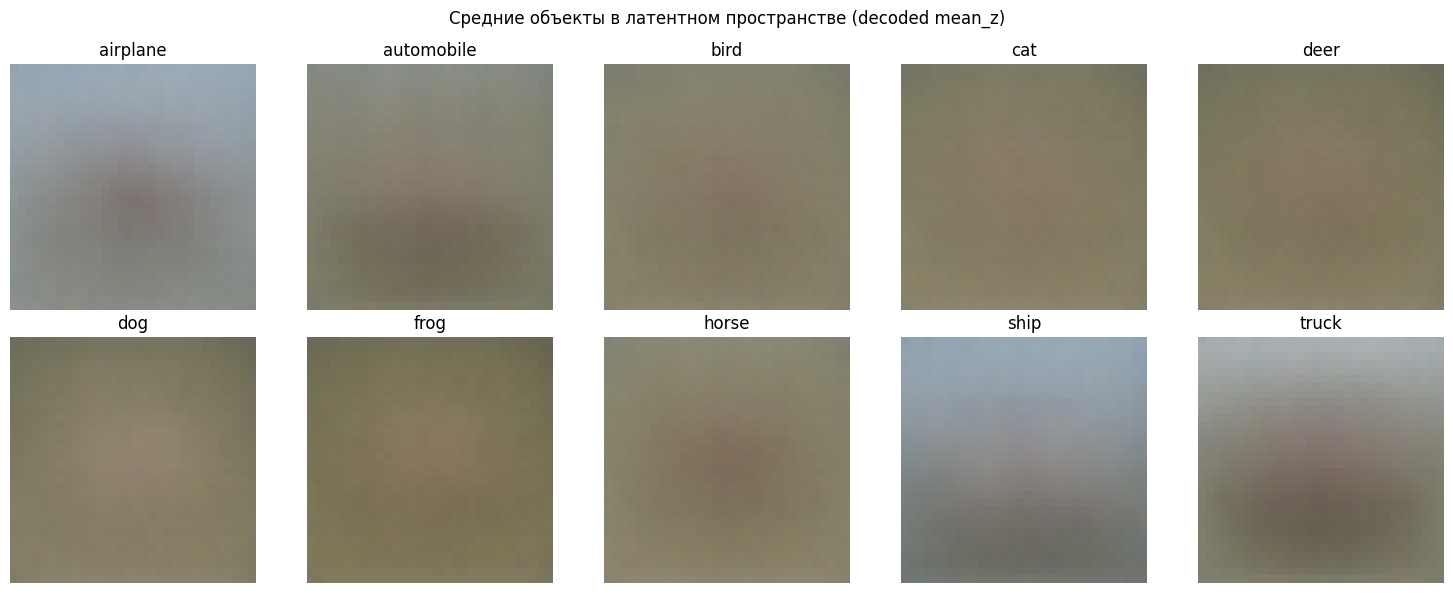

In [11]:
# Конвертируем из CHW [-1,1] в HWC [0,1] для imshow
decoded_means_show = ((decoded_means.transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for cls in range(N_CLASSES):
    ax = axes[cls // 5][cls % 5]
    ax.imshow(decoded_means_show[cls])
    ax.set_title(CIFAR_CLASSES[cls])
    ax.axis('off')
plt.suptitle('Средние объекты в латентном пространстве')
plt.tight_layout()
plt.show()

In [13]:
# в VAE латентное пространство регуляризовано под N(0,1).
# cлишком малый шум -> объекты почти одинаковые, нет разнообразия
# cлишком большой шум -> объекты теряют класс
# правильный выбор sigma ~ 0.3...1.0, соразмерно масштабу N(0,1).

print(f'Генерация по {N_GENERATED} объектов на класс (noise_std={NOISE_STD})')

vae.eval()
gen_images_list = []
gen_labels_list = []

with torch.no_grad():
    for cls in range(N_CLASSES):
        z_mean = torch.tensor(class_mean_z[cls], dtype=torch.float32)

        # Повторяем mean N_GENERATED раз и добавляем шум N(0, NOISE_STD^2)
        z_rep = z_mean.unsqueeze(0).expand(N_GENERATED, -1) # (5000, 128)
        noise = torch.randn_like(z_rep) * NOISE_STD # N(0, NOISE_STD^2)
        z_noisy = z_rep + noise # (5000, 128)

        imgs_cls = []
        for start in range(0, N_GENERATED, 256):
            z_batch = z_noisy[start:start + 256].to(DEVICE)
            imgs = vae.decode(z_batch).cpu() # (B, 3, 32, 32) в [-1, 1]
            imgs = ((imgs + 1) / 2).clamp(0, 1) # -> [0, 1]
            imgs_cls.append(imgs.numpy())

        imgs_cls = np.concatenate(imgs_cls, axis=0)  # (5000, 3, 32, 32)
        gen_images_list.append(imgs_cls)
        gen_labels_list.extend([cls] * N_GENERATED)
        print(f'  {cls:2d} {CIFAR_CLASSES[cls]:12s}: {imgs_cls.shape[0]} объектов')

X_gen = np.concatenate(gen_images_list, axis=0).astype('float32')  # (50000, 3, 32, 32)
y_gen = np.array(gen_labels_list)
print(f'\nВсего сгенерировано: {X_gen.shape}')

Генерация по 5000 объектов на класс (noise_std=0.5)
   0 airplane    : 5000 объектов
   1 automobile  : 5000 объектов
   2 bird        : 5000 объектов
   3 cat         : 5000 объектов
   4 deer        : 5000 объектов
   5 dog         : 5000 объектов
   6 frog        : 5000 объектов
   7 horse       : 5000 объектов
   8 ship        : 5000 объектов
   9 truck       : 5000 объектов

Всего сгенерировано: (50000, 3, 32, 32)


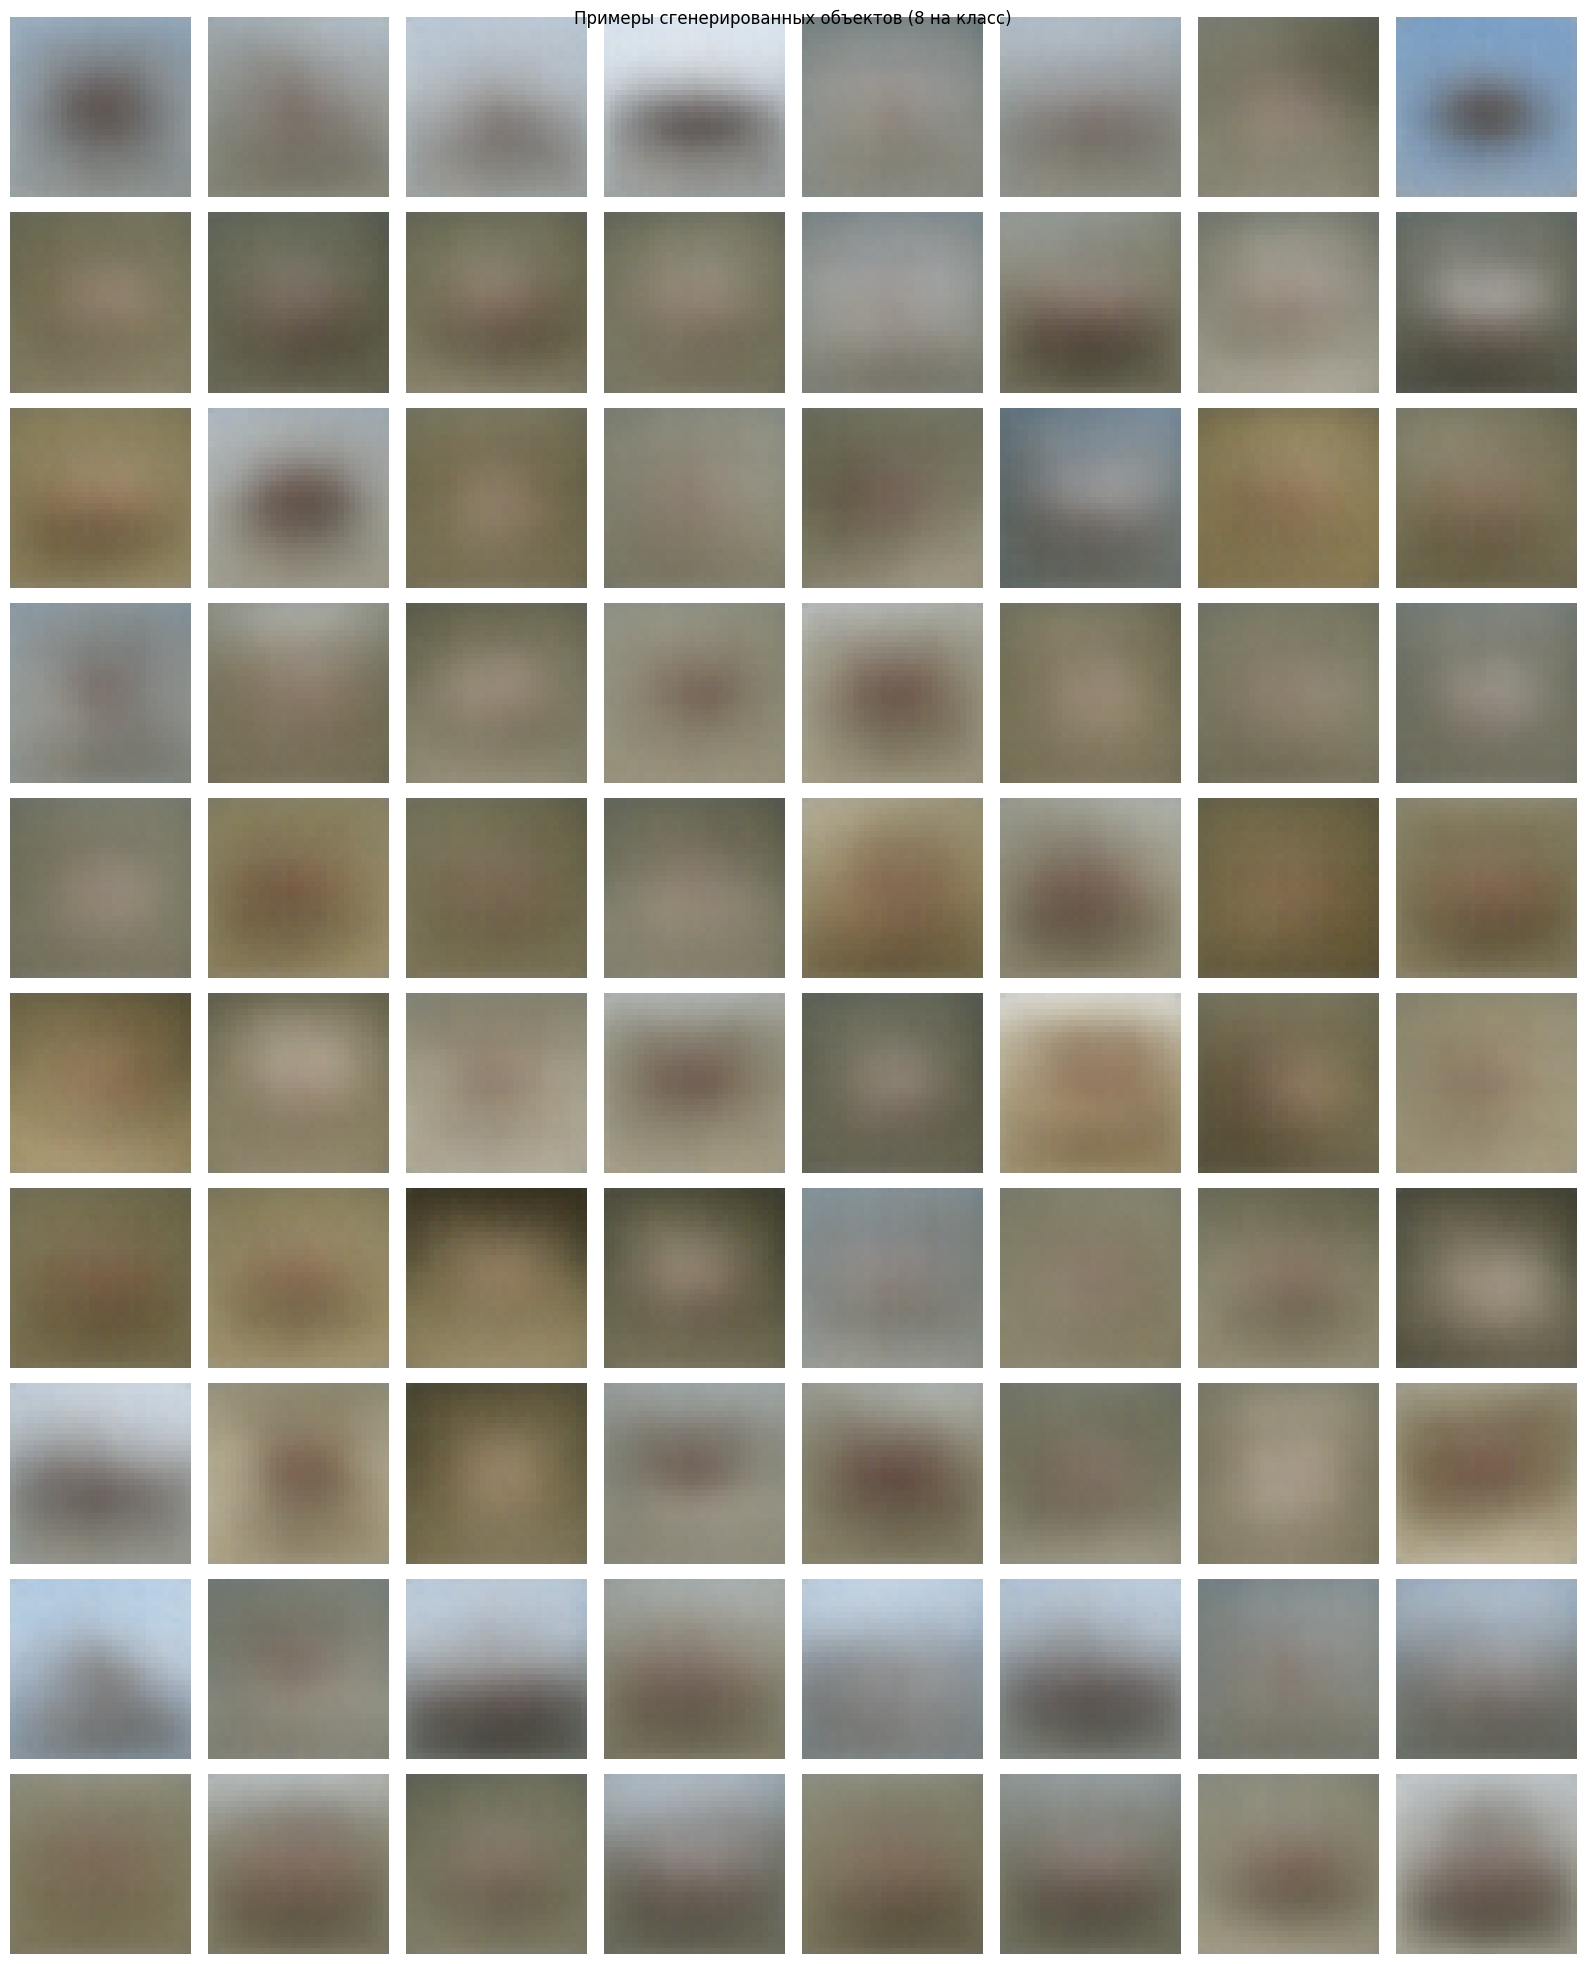

In [14]:
# Визуализация: 8 примеров на класс (конвертируем CHW -> HWC для imshow)
fig, axes = plt.subplots(N_CLASSES, 8, figsize=(16, 20))
for cls in range(N_CLASSES):
    start = cls * N_GENERATED
    for j in range(8):
        img = X_gen[start + j].transpose(1, 2, 0)  # CHW -> HWC
        axes[cls][j].imshow(img)
        axes[cls][j].axis('off')
        if j == 0:
            axes[cls][j].set_ylabel(CIFAR_CLASSES[cls], fontsize=9)
plt.suptitle('Примеры сгенерированных объектов (8 на класс)')
plt.tight_layout()
plt.show()

In [15]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1: (N, 3, 32, 32) -> (N, 32, 16, 16)
            nn.Conv2d(3,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            # Блок 2: (N, 32, 16, 16) -> (N, 64, 8, 8)
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            # Блок 3: (N, 64, 8, 8) -> (N, 128, 4, 4)
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            # Блок 4: (N, 128, 4, 4) -> (N, 256, 2, 2)
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), # (N, 256, 2, 2) -> (N, 1024)
            nn.Linear(256*2*2, 512), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_cnn(model, X_data, y_data, X_val, y_val, epochs, batch_size):
    """Обучение CNN с выводом метрик по эпохам"""
    # Создаём DataLoader
    X_t = torch.tensor(X_data, dtype=torch.float32)
    y_t = torch.tensor(y_data, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = correct = total = 0

        for x_batch, y_batch in tqdm(loader, desc=f'CNN Epoch {epoch}/{epochs}', leave=False):
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x_batch) # прямой проход
            loss = criterion(logits, y_batch) # считаем loss
            loss.backward() # градиенты
            optimizer.step() # шаг оптимизатора

            total_loss += loss.item() * len(x_batch)
            preds = logits.argmax(dim=1) # берём класс с макс. вероятностью
            correct += (preds == y_batch).sum().item()
            total += len(x_batch)

        train_loss = total_loss / total
        train_acc  = correct / total

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_preds = val_logits.argmax(dim=1)
            val_acc = (val_preds == y_val_t).float().mean().item()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d} | '
              f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
              f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    return history

In [16]:
print('CNN на реальных данных CIFAR-10')

cnn_real = CNN().to(DEVICE)
history_real = train_cnn(
    cnn_real,
    X_train_real, y_train_flat,
    X_test_real,  y_test_flat,
    epochs=CNN_EPOCHS, batch_size=CNN_BATCH
)
acc_real = history_real['val_acc'][-1]
print(f'\nТочность на реальном тесте: {acc_real*100:.2f}%')

CNN на реальных данных CIFAR-10


Epoch   1 | train_loss=1.6900 train_acc=0.3691 | val_loss=1.3816 val_acc=0.4849


Epoch   2 | train_loss=1.3510 train_acc=0.5088 | val_loss=1.1572 val_acc=0.5653


Epoch   3 | train_loss=1.1730 train_acc=0.5817 | val_loss=0.9798 val_acc=0.6478


Epoch   4 | train_loss=1.0506 train_acc=0.6310 | val_loss=0.8732 val_acc=0.6806


...

Epoch  21 | train_loss=0.3459 train_acc=0.8808 | val_loss=0.5919 val_acc=0.8189


Epoch  22 | train_loss=0.3330 train_acc=0.8837 | val_loss=0.5585 val_acc=0.8295


Epoch  23 | train_loss=0.3157 train_acc=0.8913 | val_loss=0.5627 val_acc=0.8301


Epoch  24 | train_loss=0.2950 train_acc=0.8972 | val_loss=0.5913 val_acc=0.8262


Epoch  25 | train_loss=0.2772 train_acc=0.9055 | val_loss=0.6255 val_acc=0.8228

[Baseline] Точность на реальном тесте: 82.28%


In [17]:
print('CNN на сгенерированных данных (валидация = реальный CIFAR-10)')

cnn_gen = CNN().to(DEVICE)
history_gen = train_cnn(
    cnn_gen,
    X_gen, y_gen,
    X_test_real, y_test_flat,
    epochs=CNN_EPOCHS, batch_size=CNN_BATCH
)
acc_gen = history_gen['val_acc'][-1]
print(f'\nТочность на реальном тесте: {acc_gen*100:.2f}%')

CNN на сгенерированных данных (валидация = реальный CIFAR-10)


Epoch   1 | train_loss=1.8534 train_acc=0.3082 | val_loss=2.5984 val_acc=0.2435


Epoch   2 | train_loss=1.7921 train_acc=0.3391 | val_loss=2.7088 val_acc=0.2558


Epoch   3 | train_loss=1.7789 train_acc=0.3425 | val_loss=2.7972 val_acc=0.2389


Epoch   4 | train_loss=1.7695 train_acc=0.3467 | val_loss=3.1358 val_acc=0.2489


...

Epoch  21 | train_loss=1.7108 train_acc=0.3678 | val_loss=2.4227 val_acc=0.2498


Epoch  22 | train_loss=1.7109 train_acc=0.3664 | val_loss=2.5462 val_acc=0.2498


Epoch  23 | train_loss=1.7087 train_acc=0.3678 | val_loss=2.4928 val_acc=0.2467


Epoch  24 | train_loss=1.7084 train_acc=0.3648 | val_loss=2.4802 val_acc=0.2504


Epoch  25 | train_loss=1.7054 train_acc=0.3684 | val_loss=2.4690 val_acc=0.2519

Точность на реальном тесте: 25.19%


In [18]:
print(f'CNN на реальных данных = {acc_real*100:.2f}%')
print(f'CNN на VAE-генерации = {acc_gen*100:.2f}%')
print(f'Разница = {(acc_gen - acc_real)*100:+.2f}%')

CNN на реальных данных = 82.28%
CNN на VAE-генерации = 25.19%
Разница = -57.09%
